In [2]:
import pandas as pd
import glob
import os
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Define folder path ===
folder_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata"

# === 2. Find all climate CSV files ===
all_files = glob.glob(os.path.join(folder_path, "climate-daily*.csv"))

if not all_files:
    raise FileNotFoundError(f"No files found matching pattern in: {folder_path}")

print(f"Found {len(all_files)} CSV files to merge.")

# === 3. Read and merge all CSVs ===
df_list = []
for f in all_files:
    print(f"Reading: {os.path.basename(f)}")
    df = pd.read_csv(f, low_memory=False)  # prevents DtypeWarning
    df_list.append(df)

merged_df = pd.concat(df_list, ignore_index=True)
print(f"Merged {len(df_list)} files. Shape: {merged_df.shape}")

# === 4. Keep only required columns ===
keep_cols = [
    "STATION_NAME",
    "LOCAL_DATE",
    "LOCAL_YEAR",
    "LOCAL_MONTH",
    "LOCAL_DAY",
    "TOTAL_PRECIPITATION"
]
merged_df = merged_df[keep_cols]

# === 5. Ensure LOCAL_YEAR is numeric and filter 1995–2024 ===
merged_df["LOCAL_YEAR"] = pd.to_numeric(merged_df["LOCAL_YEAR"], errors="coerce")
merged_df = merged_df[
    (merged_df["LOCAL_YEAR"] >= 1995) & (merged_df["LOCAL_YEAR"] <= 2024)
]

# === 6. Map STATION_NAME → RM ===
station_to_rm = {
    "ASSINIBOIA AIRPORT": 72,
    "BEECHY": 226,
    "BROADVIEW": 154,
    "BUTTE ST PIERRE": 501,
    "COLLINS BAY CAMECO": 344,
    "CORONACH SPC": 3,
    "CYPRESS HILLS PARK": 111,
    "DUVAL": 197,
    "EASTEND CYPRESS (AUT)": 49,
    "ELBOW CS": 254,
    "INDIAN HEAD CDA": 156,
    "KELLIHER": 247,
    "KIPLING": 124,
    "LEADER AIRPORT": 231,
    "LEROY": 339,
    "LIPTON 2": 217,
    "LUCKY LAKE": 225,
    "MANKOTA": 45,
    "MAPLE CREEK": 113,
    "OUTLOOK PFRA": 284,
    "PARKERVIEW": 191,
    "QU'APPELLE 1": 187,
    "ROCK POINT": 158,
    "ROCKGLEN (AUT)": 76,
    "ROSETOWN EAST": 321,
    "SCOTT CDA": 471,
    "SONNINGDALE": 376,
    "SPIRITWOOD WEST": 496,
    "SWIFT CURRENT CDA": 137,
    "VAL MARIE SOUTHEAST": 17,
    "WASKESIU LAKE": 488,
    "WATROUS EAST": 342,
    "WEYBURN": 67,
    "WYNYARD (AUT)": 338
}

merged_df["RMs"] = merged_df["STATION_NAME"].map(station_to_rm)

# === 7. Sort data by LOCAL_YEAR, LOCAL_MONTH, LOCAL_DAY, and RMs ===
merged_df = merged_df.sort_values(
    by=["LOCAL_YEAR", "LOCAL_MONTH", "LOCAL_DAY", "RMs"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("Data sorted by year, month, day, and RM.")

# === 8. Save final output ===
output_file = os.path.join(folder_path, "climate-daily-merged-1995-2024-with-RMs.csv")
merged_df.to_csv(output_file, index=False)

# === 9. Done ===
print(f"\n Final sorted dataset saved to:\n{output_file}")
print(f"Shape: {merged_df.shape[0]} rows × {merged_df.shape[1]} columns\n")
print(merged_df.head(10))

Found 64 CSV files to merge.
Reading: climate-daily (31).csv
Reading: climate-daily (27).csv
Reading: climate-daily (2).csv
Reading: climate-daily (50).csv
Reading: climate-daily (11).csv
Reading: climate-daily (46).csv
Reading: climate-daily (47).csv
Reading: climate-daily (10).csv
Reading: climate-daily (51).csv
Reading: climate-daily (3).csv
Reading: climate-daily (26).csv
Reading: climate-daily (30).csv
Reading: climate-daily (4).csv
Reading: climate-daily (56).csv
Reading: climate-daily (17).csv
Reading: climate-daily (40).csv
Reading: climate-daily.csv
Reading: climate-daily (37).csv
Reading: climate-daily (60).csv
Reading: climate-daily (21).csv
Reading: climate-daily (8).csv
Reading: climate-daily (9).csv
Reading: climate-daily (20).csv
Reading: climate-daily (61).csv
Reading: climate-daily (36).csv
Reading: climate-daily (41).csv
Reading: climate-daily (16).csv
Reading: climate-daily (57).csv
Reading: climate-daily (5).csv
Reading: climate-daily (42).csv
Reading: climate-daily

In [3]:
# Filter rows where TOTAL_PRECIPITATION is missing
missing_precip = merged_df[merged_df['TOTAL_PRECIPITATION'].isna()]

# Get unique RMs and Station Names for those rows
unique_RMs = sorted(missing_precip['RMs'].dropna().unique())
unique_stations = sorted(missing_precip['STATION_NAME'].dropna().unique())

print("Unique RMs with missing TOTAL_PRECIPITATION:")
print(unique_RMs)

print("\nUnique STATION_NAMEs with missing TOTAL_PRECIPITATION:")
print(unique_stations)

# Count of unique station names
print(f"\nTotal unique stations with missing TOTAL_PRECIPITATION: {len(unique_stations)}")

Unique RMs with missing TOTAL_PRECIPITATION:
[3, 17, 45, 49, 67, 72, 76, 111, 113, 124, 137, 154, 156, 158, 191, 197, 217, 225, 231, 247, 254, 284, 321, 338, 342, 344, 376, 471, 488, 496, 501]

Unique STATION_NAMEs with missing TOTAL_PRECIPITATION:
['ASSINIBOIA AIRPORT', 'BROADVIEW', 'BUTTE ST PIERRE', 'COLLINS BAY CAMECO', 'CORONACH SPC', 'CYPRESS HILLS PARK', 'DUVAL', 'EASTEND CYPRESS (AUT)', 'ELBOW CS', 'INDIAN HEAD CDA', 'KELLIHER', 'KIPLING', 'LEADER AIRPORT', 'LIPTON 2', 'LUCKY LAKE', 'MANKOTA', 'MAPLE CREEK', 'OUTLOOK PFRA', 'PARKERVIEW', 'ROCK POINT', 'ROCKGLEN (AUT)', 'ROSETOWN EAST', 'SCOTT CDA', 'SONNINGDALE', 'SPIRITWOOD WEST', 'SWIFT CURRENT CDA', 'VAL MARIE SOUTHEAST', 'WASKESIU LAKE', 'WATROUS EAST', 'WEYBURN', 'WYNYARD (AUT)']

Total unique stations with missing TOTAL_PRECIPITATION: 31


In [4]:
# Group by RMs and check which have no missing TOTAL_PRECIPITATION
complete_RMs = (
    merged_df.groupby('RMs')['TOTAL_PRECIPITATION']
    .apply(lambda x: x.notna().all())  # True if all values are non-missing
)
# Filter to keep only RMs with complete data
RMs_with_complete_data = sorted(complete_RMs[complete_RMs].index.tolist())

print("RMs with complete TOTAL_PRECIPITATION data for the whole range:")
print(RMs_with_complete_data)

# Count of complete RMs
print(f"\nTotal RMs with complete precipitation data: {len(RMs_with_complete_data)}")

RMs with complete TOTAL_PRECIPITATION data for the whole range:
[187, 226, 339]

Total RMs with complete precipitation data: 3


In [5]:
# filter RMs with complete TOTAL_PRECIPITATION data for the whole range: 187, 226, 339
filtered_df = merged_df[merged_df["RMs"].isin([187, 226, 339])]
print(filtered_df.head(25))
# save it to the folder for review
filtered_df_output = os.path.join(folder_path, "filtered_precipitation.csv")
filtered_df.to_csv(filtered_df_output, index=False)

     STATION_NAME           LOCAL_DATE  LOCAL_YEAR  LOCAL_MONTH  LOCAL_DAY  \
14   QU'APPELLE 1  1995-01-01 00:00:00        1995            1          1   
19         BEECHY  1995-01-01 00:00:00        1995            1          1   
26          LEROY  1995-01-01 00:00:00        1995            1          1   
48   QU'APPELLE 1  1995-01-02 00:00:00        1995            1          2   
53         BEECHY  1995-01-02 00:00:00        1995            1          2   
60          LEROY  1995-01-02 00:00:00        1995            1          2   
82   QU'APPELLE 1  1995-01-03 00:00:00        1995            1          3   
87         BEECHY  1995-01-03 00:00:00        1995            1          3   
94          LEROY  1995-01-03 00:00:00        1995            1          3   
116  QU'APPELLE 1  1995-01-04 00:00:00        1995            1          4   
121        BEECHY  1995-01-04 00:00:00        1995            1          4   
128         LEROY  1995-01-04 00:00:00        1995            1 

In [6]:
# Drop unneeded columns
precip = filtered_df.drop(columns=['STATION_NAME', 'LOCAL_DATE'])

# --- Create full set of (year, RM, month, day) combinations
years = precip['LOCAL_YEAR'].unique()
rms = precip['RMs'].unique()
months = range(1, 13)
days = range(1, 32)

full_index = pd.MultiIndex.from_product(
    [years, rms, months, days],
    names=['LOCAL_YEAR', 'RMs', 'LOCAL_MONTH', 'LOCAL_DAY']
)

# --- Reindex to ensure every combo exists, fill missing with 0
precip_full = (
    precip.set_index(['LOCAL_YEAR', 'RMs', 'LOCAL_MONTH', 'LOCAL_DAY'])
           .reindex(full_index, fill_value=0)
           .reset_index()
)

# --- Pivot months into columns
precip_wide = precip_full.pivot_table(
    index=['LOCAL_YEAR', 'RMs', 'LOCAL_DAY'],
    columns='LOCAL_MONTH',
    values='TOTAL_PRECIPITATION',
    aggfunc='sum',
    fill_value=0
).reset_index()

# --- Clean up column names
precip_wide.columns.name = None
precip_wide = precip_wide.rename(columns={
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})
precip_wide.tail(10)

,LOCAL_YEAR,RMs,LOCAL_DAY,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2780,2024,339,22,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.2,0.0
2781,2024,339,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.6,0.6,0.0,21.2,0.0
2782,2024,339,24,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.0,6.0,0.0
2783,2024,339,25,0.0,11.0,0.0,0.0,0.0,6.2,0.0,0.0,0.0,0.0,0.0,0.0
2784,2024,339,26,0.0,2.6,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2785,2024,339,27,0.0,0.0,0.0,0.0,0.0,21.4,0.0,0.0,0.0,0.0,0.8,2.8
2786,2024,339,28,0.0,0.0,4.8,0.0,0.0,1.4,0.0,3.4,0.0,0.0,0.0,0.0
2787,2024,339,29,0.0,0.0,1.4,0.0,2.2,0.0,0.0,0.6,0.4,0.0,0.0,0.0
2788,2024,339,30,0.0,0.0,0.0,0.0,2.8,4.6,0.0,0.0,3.4,0.0,5.6,0.0
2789,2024,339,31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Keep only desired months (May–Oct)
precip_wide = precip_wide[['LOCAL_YEAR', 'RMs', 'LOCAL_DAY', 
                           'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']]
#The canola crop cycle in Saskatchewan typically spans from early May to September/October,
# We will focus 6 month period May to October (so we will have 18 10 days period)
##### it will be beneficial May-August 4 months/ but research about the timeline
precip_wide.head(5)

,LOCAL_YEAR,RMs,LOCAL_DAY,May,Jun,Jul,Aug,Sep,Oct
0,1995,187,1,0.0,0.0,2.5,0.0,0.0,21.2
1,1995,187,2,0.0,0.0,0.0,1.1,0.0,0.4
2,1995,187,3,0.4,0.0,0.0,0.0,0.0,0.0
3,1995,187,4,0.0,0.0,0.0,0.0,0.0,0.0
4,1995,187,5,0.0,53.8,0.8,0.0,34.2,0.0


In [8]:
# --- Starting point ------------------------------------------
# precip_wide has columns:
# ['LOCAL_YEAR', 'RMs', 'LOCAL_DAY', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']

# --- Convert from wide (months as columns) to long format ----
precip_long = precip_wide.melt(
    id_vars=['LOCAL_YEAR', 'RMs', 'LOCAL_DAY'],
    value_vars=['May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct'],
    var_name='Month',
    value_name='Rain'
)

# --- Assign each (Month, LOCAL_DAY) a sequential "day index" (1–183) ----
# We'll use approximate month day lengths
month_days = {'May': 31, 'Jun': 30, 'Jul': 31, 'Aug': 31, 'Sep': 30, 'Oct': 31}

# Compute an offset for each month
month_order = ['May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']
month_offsets = {}
cumulative = 0
for m in month_order:
    month_offsets[m] = cumulative
    cumulative += month_days[m]

# Map to overall day index (1–183)
precip_long['Day_Index'] = precip_long.apply(
    lambda x: month_offsets[x['Month']] + x['LOCAL_DAY']
    if x['LOCAL_DAY'] <= month_days[x['Month']] else np.nan,
    axis=1
)

# Drop invalid day/month combos (e.g. June 31)
precip_long = precip_long.dropna(subset=['Day_Index'])

# --- Assign 10-day subperiods --------------------------------
precip_long['Subperiod'] = np.ceil(precip_long['Day_Index'] / 10).astype(int)

# --- Aggregate rainfall per subperiod per year & RM i.e. sum of daily rainfall in each 10-day subperiod--
subperiod_sum = (
    precip_long
    .groupby(['LOCAL_YEAR', 'RMs', 'Subperiod'], as_index=False)['Rain']
    .sum()
)

# --- Pivot to wide format: one row per (year, RM), columns = Period_1 ... Period_19
subperiod_wide = subperiod_sum.pivot_table(
    index=['LOCAL_YEAR', 'RMs'],
    columns='Subperiod',
    values='Rain',
    fill_value=0
).reset_index()

# Rename columns to Period_1, Period_2, ...
subperiod_wide.columns.name = None
subperiod_wide = subperiod_wide.rename(columns={i: f'Period_{i}' for i in range(1, 20)})
subperiod_wide = subperiod_wide.drop(columns=['Period_19']) # last 10 days in October droppped

# --- Save the result -----------------------------------------
subperiod_wide.to_csv('/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/subperiod_rainfall.csv', index=False)

print(subperiod_wide.shape)
print(subperiod_wide.head())

(90, 20)
   LOCAL_YEAR  RMs  Period_1  Period_2  Period_3  Period_4  Period_5  \
0        1995  187      11.9      12.6      51.4      54.4      34.3   
1        1995  226       8.6      23.4      19.9       4.6      37.0   
2        1995  339       1.2      22.4       5.6      54.8      45.8   
3        1996  187      11.0      24.5       0.4      14.3      21.7   
4        1996  226      17.4      77.7       2.2      16.8      38.6   

   Period_6  Period_7  Period_8  Period_9  Period_10  Period_11  Period_12  \
0      23.1      10.2      17.8      13.5       12.7       77.0       47.5   
1       8.6      28.1       6.0      11.0       17.4       52.9       11.0   
2      45.8      27.0      12.0      18.4       28.4      114.0       16.2   
3      34.9       9.8      29.7       7.6        3.7       16.2        0.2   
4      37.6       5.1      32.0      19.9        1.6       19.2        0.0   

   Period_13  Period_14  Period_15  Period_16  Period_17  Period_18  
0       36.1       

In [9]:
# --- Step 1: Load the dataset ---
file1_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/RM-Canola-1992_2024.csv"
df1 = pd.read_csv(file1_path)

# --- Step 2: Keep only needed columns ---
df1 = df1[['Year', 'RM', 'Canola']]

# --- Step 3: Filter by RM list and Year range ---
rm_list = [187, 226, 339]

yield_filtered = df1[
    (df1['RM'].isin(rm_list)) &
    (df1['Year'].between(1995, 2024))
].reset_index(drop=True)

# --- Step 4: Define output path and save ---
output_folder = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata"
output_file = os.path.join(output_folder, "RM_canola_yield_1995_2024.csv")

yield_filtered.to_csv(output_file, index=False)

print(f" Filtered Canola dataset saved successfully to:\n{output_file}")
print(f"Shape: {yield_filtered.shape[0]} rows × {yield_filtered.shape[1]} columns")
print(yield_filtered.head())

 Filtered Canola dataset saved successfully to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/RM_canola_yield_1995_2024.csv
Shape: 90 rows × 3 columns
   Year   RM  Canola
0  1995  187    15.0
1  1996  187    20.5
2  1997  187    19.0
3  1998  187    23.7
4  1999  187    22.7


In [10]:
# ---- path for output ----
out_dir = '/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results'
os.makedirs(out_dir, exist_ok=True)

# ---- Constants ----
price_per_kg = 13.73     # CAD per kg (updated; no area used)

# ---- Load ----
sub = subperiod_wide
yld = yield_filtered

# ---- Quick checks & normalize column names ----
print("subperiod shape:", sub.shape)
print("first rows of subperiod:")
print(sub.head())

print("yield shape:", yld.shape)
print("first rows of yield:")
print(yld.head())

# Standardize column names for merging
sub.columns = [c.strip() for c in sub.columns]
yld.columns = [c.strip() for c in yld.columns]

# Rename yield columns to match merge keys
# yield file looks like: Year, RM, Canola  -> map to LOCAL_YEAR, RMs, Yield_kg_ha
yld = yld.rename(columns={'Year':'LOCAL_YEAR', 'RM':'RMs', 'Canola':'Yield_raw'})

# Convert types
sub['LOCAL_YEAR'] = sub['LOCAL_YEAR'].astype(int)
sub['RMs'] = sub['RMs'].astype(int)
yld['LOCAL_YEAR'] = yld['LOCAL_YEAR'].astype(int)
yld['RMs'] = yld['RMs'].astype(int)

# ---- Use yield as-is (no unit conversion) ----
yld['Yield_kg_ha'] = yld['Yield_raw'].astype(float)

# ---- Ensure Period_1..Period_18 exist (no capping applied) ----
period_cols = [f'Period_{i}' for i in range(1, 19)]
missing_periods = [c for c in period_cols if c not in sub.columns]
if missing_periods:
    raise ValueError(f"Missing expected period columns in subperiod file: {missing_periods}")

# ---- Merge yields into the rainfall table ----
df = sub.merge(yld[['LOCAL_YEAR','RMs','Yield_kg_ha']], on=['LOCAL_YEAR','RMs'], how='left')

# Report any missing yields
missing_y = df[df['Yield_kg_ha'].isna()][['LOCAL_YEAR','RMs']].drop_duplicates()
if not missing_y.empty:
    print("Warning: missing yield for these (year, RM) rows (showing up to 20):")
    print(missing_y.head(20))
else:
    print("All years/RMs have yield entries merged successfully.")

# Save the merged table for the next chunk
merged_path = os.path.join(out_dir, 'merged_subperiods_yield_clean.csv')
df.to_csv(merged_path, index=False)
print("Saved merged file to:", merged_path)

# Show a couple rows ready for next step
print(df[['LOCAL_YEAR','RMs','Yield_kg_ha'] + period_cols].head(3))


subperiod shape: (90, 20)
first rows of subperiod:
   LOCAL_YEAR  RMs  Period_1  Period_2  Period_3  Period_4  Period_5  \
0        1995  187      11.9      12.6      51.4      54.4      34.3   
1        1995  226       8.6      23.4      19.9       4.6      37.0   
2        1995  339       1.2      22.4       5.6      54.8      45.8   
3        1996  187      11.0      24.5       0.4      14.3      21.7   
4        1996  226      17.4      77.7       2.2      16.8      38.6   

   Period_6  Period_7  Period_8  Period_9  Period_10  Period_11  Period_12  \
0      23.1      10.2      17.8      13.5       12.7       77.0       47.5   
1       8.6      28.1       6.0      11.0       17.4       52.9       11.0   
2      45.8      27.0      12.0      18.4       28.4      114.0       16.2   
3      34.9       9.8      29.7       7.6        3.7       16.2        0.2   
4      37.6       5.1      32.0      19.9        1.6       19.2        0.0   

   Period_13  Period_14  Period_15  Period_16  

In [11]:
##################### SPLIT CLEAN VS MISSING ROWS ############################

# Path to merged file created in previous chunk
merged_path = os.path.join(out_dir, 'merged_subperiods_yield_clean.csv')

# Load the merged dataset
df2 = pd.read_csv(merged_path)

print("Loaded merged file:", df2.shape)

# Identify rows with missing yield
missing_rows = df2[df2['Yield_kg_ha'].isna()].copy()
clean_rows = df2[df2['Yield_kg_ha'].notna()].copy()

print(f"Rows with missing yield: {len(missing_rows)}")
print(f"Rows with complete yield: {len(clean_rows)}")

# Save missing rows
missing_out = os.path.join(out_dir, 'missing_yield_rows.csv')
missing_rows.to_csv(missing_out, index=False)
print(f"Saved missing rows to: {missing_out}")

# Save clean rows
clean_out = os.path.join(out_dir, 'clean_merged_yield_data.csv')
clean_rows.to_csv(clean_out, index=False)
print(f"Saved clean rows to: {clean_out}")

# Preview clean rows
print("\nPreview of clean rows:")
print(clean_rows.head(3))


Loaded merged file: (90, 21)
Rows with missing yield: 1
Rows with complete yield: 89
Saved missing rows to: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results/missing_yield_rows.csv
Saved clean rows to: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results/clean_merged_yield_data.csv

Preview of clean rows:
   LOCAL_YEAR  RMs  Period_1  Period_2  Period_3  Period_4  Period_5  \
0        1995  187      11.9      12.6      51.4      54.4      34.3   
1        1995  226       8.6      23.4      19.9       4.6      37.0   
2        1995  339       1.2      22.4       5.6      54.8      45.8   

   Period_6  Period_7  Period_8  ...  Period_10  Period_11  Period_12  \
0      23.1      10.2      17.8  ...       12.7       77.0       47.5   
1       8.6      28.1       6.0  ...       17.4       52.9       11.0   
2      45.8      27.0      12.0  ...       28.4      114.0       16.2   

   Period_13  Period_14  Period_15  Period_16  Period_17  Period

In [12]:
##################### SPLIT CLEAN VS MISSING ROWS ############################

# Path to merged file created in previous chunk
merged_path = os.path.join(out_dir, 'merged_subperiods_yield_clean.csv')

# Load it
df2 = pd.read_csv(merged_path)

# Identify missing-yield rows
missing_rows = df2[df2['Yield_kg_ha'].isna()].copy()
clean_rows = df2[df2['Yield_kg_ha'].notna()].copy()

# Save missing rows separately
missing_out = os.path.join(out_dir, 'missing_yield_rows.csv')
missing_rows.to_csv(missing_out, index=False)
print(f"Saved missing rows to: {missing_out}")

# Save clean rows separately
clean_out = os.path.join(out_dir, 'clean_merged_yield_data.csv')
clean_rows.to_csv(clean_out, index=False)
print(f"Saved clean rows to: {clean_out}")

# Preview
print("Preview of clean rows:")
print(clean_rows.head(3))


Saved missing rows to: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results/missing_yield_rows.csv
Saved clean rows to: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results/clean_merged_yield_data.csv
Preview of clean rows:
   LOCAL_YEAR  RMs  Period_1  Period_2  Period_3  Period_4  Period_5  \
0        1995  187      11.9      12.6      51.4      54.4      34.3   
1        1995  226       8.6      23.4      19.9       4.6      37.0   
2        1995  339       1.2      22.4       5.6      54.8      45.8   

   Period_6  Period_7  Period_8  ...  Period_10  Period_11  Period_12  \
0      23.1      10.2      17.8  ...       12.7       77.0       47.5   
1       8.6      28.1       6.0  ...       17.4       52.9       11.0   
2      45.8      27.0      12.0  ...       28.4      114.0       16.2   

   Period_13  Period_14  Period_15  Period_16  Period_17  Period_18  \
0       36.1        7.4        0.6       22.7       31.0       15.8   
1       

In [13]:
import numpy as np
from scipy.stats import pearsonr

# Use the cleaned dataset
df_clean = clean_rows.copy()

period_cols = [f'Period_{i}' for i in range(1, 19)]

# Equal weights for 18 subperiods
equal_weights = np.ones(18) / 18.0

# Compute rainfall index
df_clean['Rainfall_Index_equal'] = df_clean[period_cols].values.dot(equal_weights)

# Compute correlation (now guaranteed to have no NaNs)
corr_equal, _ = pearsonr(df_clean['Rainfall_Index_equal'], df_clean['Yield_kg_ha'])

print(f"Correlation (equal weights): {corr_equal:.4f}")


Correlation (equal weights): 0.1275


In [14]:
from scipy.optimize import minimize

# ---- Use the cleaned dataset ----
df_clean = clean_rows.copy()

X = df_clean[period_cols].values      # shape (n_years, 18)
y = df_clean['Yield_kg_ha'].values    # shape (n_years,)

def neg_corr(weights):
    """Return negative correlation (since we minimize)."""
    F = X.dot(weights)
    corr = np.corrcoef(F, y)[0, 1]
    return -corr  # minimize the negative correlation

# Initial equal weights
w0 = np.ones(18) / 18.0

# Constraints: 0 ≤ wi ≤ 1 and sum(wi) = 1
bounds = [(0, 1)] * 18
cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

# Optimization
result = minimize(neg_corr, w0, method='SLSQP', bounds=bounds, constraints=cons)

# Results
opt_weights = result.x
F_opt = X.dot(opt_weights)
corr_opt = np.corrcoef(F_opt, y)[0, 1]

print("Optimized weights per subperiod:")
print(np.round(opt_weights, 4))
print(f"\nCorrelation (optimized weights): {corr_opt:.4f}")

# Save optimized rainfall index
df_clean['Rainfall_Index_opt'] = F_opt


Optimized weights per subperiod:
[0.     0.0007 0.     0.0877 0.     0.0818 0.     0.1448 0.067  0.0098
 0.     0.     0.     0.0447 0.2737 0.1795 0.     0.1102]

Correlation (optimized weights): 0.4299


In [15]:
# Recompute Equal-weight rainfall index in df_clean
equal_weights = np.ones(18) / 18.0
df_clean['Rainfall_Index_equal'] = df_clean[period_cols].values.dot(equal_weights)

# Recompute optimized rainfall index in df_clean
opt_weights = opt_weights  # keep the optimized weights you already found
df_clean['Rainfall_Index_opt'] = df_clean[period_cols].values.dot(opt_weights)

In [16]:
# ---- Compute strike prices (K) for each RM using CLEAN dataset ----
strike_equal = (
    df_clean.groupby("RMs")["Rainfall_Index_equal"]
        .mean()
        .reset_index()
        .rename(columns={"Rainfall_Index_equal": "K_equal"})
)

strike_opt = (
    df_clean.groupby("RMs")["Rainfall_Index_opt"]
        .mean()
        .reset_index()
        .rename(columns={"Rainfall_Index_opt": "K_opt"})
)

strike_prices = strike_equal.merge(strike_opt, on="RMs", how="outer")

print("Strike prices (average rainfall index per RM):")
print(strike_prices)


Strike prices (average rainfall index per RM):
   RMs    K_equal      K_opt
0  187  18.487593  16.111317
1  226  15.279502  13.913700
2  339  17.527037  14.961608


In [17]:
# --- DATA FOR YIELD 1990-1994 ---
import pandas as pd
import os

# --- DATA FOR YIELD 1990-1994 ---
file1_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/RM-Canola-1992_2024.csv"
df1 = pd.read_csv(file1_path)

# --- Step 1: Keep only needed columns ---
df1 = df1[['Year', 'RM', 'Canola']]

# --- Step 2: Filter by RM list and Year range ---
rm_list = [187, 226, 339]

y_filtered = df1[
    (df1['RM'].isin(rm_list)) &
    (df1['Year'].between(1990, 1994))
].reset_index(drop=True)

# --- Step 3: DROP rows with missing yield ---
y_clean = y_filtered.dropna(subset=["Canola"]).reset_index(drop=True)

# --- Step 4: Save cleaned file ---
output_folder = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata"
output_file = os.path.join(output_folder, "RM_canola_yield_1990_1994_CLEAN.csv")

y_clean.to_csv(output_file, index=False)

print(f" Cleaned Canola dataset saved successfully to:\n{output_file}")
print(f"Shape: {y_clean.shape[0]} rows × {y_clean.shape[1]} columns")
print(y_clean)

 Cleaned Canola dataset saved successfully to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/RM_canola_yield_1990_1994_CLEAN.csv
Shape: 14 rows × 3 columns
    Year   RM  Canola
0   1990  187    19.0
1   1992  187    25.0
2   1993  187    24.9
3   1994  187    21.6
4   1990  226    20.0
5   1991  226    22.0
6   1992  226    20.0
7   1993  226    30.0
8   1994  226    23.0
9   1990  339    15.0
10  1991  339    21.0
11  1992  339    27.2
12  1993  339    22.6
13  1994  339    24.3


In [18]:
early_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/RM_canola_yield_1990_1994_CLEAN.csv"
df_early = pd.read_csv(early_path)

df_early = df_early.rename(columns={"Year": "LOCAL_YEAR", "RM": "RMs", "Canola": "Yield_raw"})

df_early["Yield_kg_ha"] = df_early["Yield_raw"]
df_early = df_early[["LOCAL_YEAR", "RMs", "Yield_kg_ha"]]

df_all = pd.concat([df_early, df_clean], ignore_index=True)
df_all = df_all.sort_values(["RMs", "LOCAL_YEAR"]).reset_index(drop=True)

df_all["Yield_MA5"] = (
    df_all.groupby("RMs")["Yield_kg_ha"]
          .transform(lambda x: x.rolling(window=5, min_periods=5).mean())
)

# ------------------ Keep only years ≥ 1995 for final dataset ------------------
df_clean = df_all[df_all["LOCAL_YEAR"] >= 1995].reset_index(drop=True)

# ------------------ Preview ------------------
print(df_clean[["LOCAL_YEAR", "RMs", "Yield_kg_ha", "Yield_MA5"]].head(10))

   LOCAL_YEAR  RMs  Yield_kg_ha  Yield_MA5
0        1995  187         15.0      21.10
1        1996  187         20.5      21.40
2        1997  187         19.0      20.20
3        1998  187         23.7      19.96
4        1999  187         22.7      20.18
5        2000  187         24.0      21.98
6        2001  187         21.3      22.14
7        2002  187         18.9      22.12
8        2003  187         12.6      19.90
9        2004  187         22.7      19.90


In [19]:
# ---- Assign fixed canola price (CAD $/kg) ----
price_canola = 13.73   # updated price
df_clean["Price"] = price_canola

# ---- Check ----
print(df_clean[["RMs", "Price"]].drop_duplicates())


    RMs  Price
0   187  13.73
30  226  13.73
59  339  13.73


In [20]:
# ---- Compute theta: expected revenue per hectare ----
df_clean["theta"] = df_clean["Yield_MA5"] * df_clean["Price"]

# Preview
print(df_clean[["RMs", "LOCAL_YEAR", "Yield_MA5", "Price", "theta"]].head())


   RMs  LOCAL_YEAR  Yield_MA5  Price     theta
0  187        1995      21.10  13.73  289.7030
1  187        1996      21.40  13.73  293.8220
2  187        1997      20.20  13.73  277.3460
3  187        1998      19.96  13.73  274.0508
4  187        1999      20.18  13.73  277.0714


In [21]:
# ---- Merge strike prices per RM using CLEAN dataset ----
df_clean = df_clean.merge(strike_prices, on="RMs", how="left")

# ---- Clean up any duplicate suffixes ----
# If K_equal_x exists, prefer it. If not (e.g., different merge behavior), fallback safely.
rename_map = {}

if "K_equal_x" in df_clean.columns:
    rename_map["K_equal_x"] = "K_equal"
if "K_opt_x" in df_clean.columns:
    rename_map["K_opt_x"] = "K_opt"

df_clean = df_clean.rename(columns=rename_map)

# Drop any leftover *_y columns if present
drop_cols = [c for c in df_clean.columns if c.endswith("_y")]
df_clean = df_clean.drop(columns=drop_cols, errors='ignore')

# Final check
print([c for c in df_clean.columns if "K" in c])


['K_equal', 'K_opt']


In [22]:
# ---- Indemnity based on optimized strike price ----
df_clean["Indemnity_opt"] = np.where(
    df_clean["Rainfall_Index_opt"] < df_clean["K_opt"],
    df_clean["theta"] * (df_clean["K_opt"] - df_clean["Rainfall_Index_opt"]) / df_clean["K_opt"],
    0
)

# ---- Indemnity based on equal strike price ----
df_clean["Indemnity_equal"] = np.where(
    df_clean["Rainfall_Index_equal"] < df_clean["K_equal"],
    df_clean["theta"] * (df_clean["K_equal"] - df_clean["Rainfall_Index_equal"]) / df_clean["K_equal"],
    0
)


# ---- Check ----
print(df_clean[["RMs", "LOCAL_YEAR", "Indemnity_opt", "Indemnity_equal"]].head(30))


    RMs  LOCAL_YEAR  Indemnity_opt  Indemnity_equal
0   187        1995       0.000000         0.000000
1   187        1996      16.088570        97.014560
2   187        1997     101.545836        88.657487
3   187        1998       0.000000         0.000000
4   187        1999       3.975033         0.000000
5   187        2000      58.302911         0.000000
6   187        2001     159.010764       186.144299
7   187        2002      92.909407         0.000000
8   187        2003     178.456451       170.020744
9   187        2004     100.468041         0.000000
10  187        2005      80.487741         0.000000
11  187        2006       4.962713        86.067919
12  187        2007      34.071385        12.531495
13  187        2008       0.000000        12.372436
14  187        2009       0.000000         0.000000
15  187        2010       0.000000         0.000000
16  187        2011       0.000000         0.000000
17  187        2012      19.342214         0.000000
18  187     

In [23]:
# ---- Assign fixed canola price (CAD $/kg) ----
df_clean["Price"] = 13.73

# ---- Check ----
print(df_clean[["RMs", "Price"]].drop_duplicates())


    RMs  Price
0   187  13.73
30  226  13.73
59  339  13.73


In [25]:
# ---- Revenue without derivative ----
price_canola = 13.73  # per bushels 
df_clean["Revenue"] = df_clean["Yield_kg_ha"] * df_clean["Price"]


# ---- Revenue with derivative (optimized indemnity) ----
# assuming premium pr = 0 for now
df_clean["Revenue_with_derivative_opt"] = (
    df_clean["Revenue"] + df_clean["Indemnity_opt"]
)

# ---- Revenue with derivative (equal-weight indemnity) ----
df_clean["Revenue_with_derivative_equal"] = (
    df_clean["Revenue"] + df_clean["Indemnity_equal"]
)


In [26]:
def monte_carlo_premium(F_index, theta, K, n_sim=5000, seed=42):
    """
    Compute fair option premium using Monte Carlo simulation.

    Parameters:
    - F_index : array-like of historical rainfall index (optimized or equal-weight)
    - theta   : array-like of max indemnity per year (same length as F_index) OR scalar
    - K       : strike price (scalar or array-like same length as F_index)
    - n_sim   : int, number of Monte Carlo simulations
    - seed    : int, random seed

    Returns:
    - premium : float, estimated fair premium
    """
    import numpy as np

    np.random.seed(seed)

    # Convert inputs to arrays
    F_index = np.asarray(F_index, dtype=float)
    theta = np.asarray(theta, dtype=float)

    # Allow scalar theta
    if theta.size == 1:
        theta = np.full_like(F_index, theta)

    # Allow scalar K
    if np.isscalar(K):
        K = np.full_like(F_index, K, dtype=float)
    else:
        K = np.asarray(K, dtype=float)

    # Safety check
    if not (len(F_index) == len(theta) == len(K)):
        raise ValueError("F_index, theta, and K must be same length or scalars.")

    # Fit normal distribution
    mu = np.mean(F_index)
    sigma = np.std(F_index)

    # Prevent degenerate cases
    if sigma == 0:
        sigma = 1e-6

    # Simulated rainfall indices: shape (n_sim, n_years)
    sim_F = np.random.normal(loc=mu, scale=sigma, size=(n_sim, len(F_index)))

    # Reshape K and theta for broadcasting
    K_mat = K.reshape(1, -1)
    theta_mat = theta.reshape(1, -1)

    # Payoff matrix (n_sim × n_years)
    sim_payoffs = np.where(
        sim_F < K_mat,
        theta_mat * (K_mat - sim_F) / K_mat,
        0
    )

    # Expected premium = average over all simulations and years
    premium = sim_payoffs.mean()

    return premium


In [37]:
# ---- Compute Monte Carlo premiums per RM using df_clean ----
premium = {}

for rm in df_clean["RMs"].unique():
    df_rm = df_clean[df_clean["RMs"] == rm]

    # Optimized rainfall index
    F_index = df_rm["Rainfall_Index_opt"].values
    theta   = df_rm["theta"].values
    K       = df_rm["K_opt"].values[0]    # scalar per RM

    # Compute premium using Monte Carlo
    pr = monte_carlo_premium(F_index, theta, K, n_sim=10000)

    # Store in dictionary
    premium[rm] = pr

# ---- Display estimated premiums ----
print("Estimated option premiums per RM (CAD $):")
for rm, pr in premium.items():
    print(f"RM {rm}: {pr:,.2f}")


Estimated option premiums per RM (CAD $):
RM 187: 63.03
RM 226: 60.27
RM 339: 57.04


In [38]:
import pandas as pd

# Interest rate table you provided
rate_data = {
    "LOCAL_YEAR": [
        1995, 1996, 1997, 1998, 1999,
        2000, 2001, 2002, 2003, 2004,
        2005, 2006, 2007, 2008, 2009,
        2010, 2011, 2012, 2013, 2014,
        2015, 2016, 2017, 2018, 2019,
        2020, 2021, 2022, 2023, 2024
    ],
    "rate": [
        0.0778, 0.0496, 0.035, 0.0486, 0.046,
        0.058, 0.0438, 0.0271, 0.0332, 0.0197,
        0.0255, 0.0415, 0.0424, 0.0262, 0.003,
        0.0068, 0.0111, 0.01113, 0.0101, 0.0096,
        0.0056, 0.0058, 0.0056, 0.0138, 0.0171,
        0.0032, 0.0013, 0.0188, 0.044, 0.0486
    ]
}

interest_rates_df = pd.DataFrame(rate_data)
[x for x in df_clean.columns if df_clean.columns.tolist().count(x) > 1]
df_clean = df_clean.drop(columns=[col for col in df_clean.columns if col.startswith("rate")])
df_clean = df_clean.merge(interest_rates_df, on="LOCAL_YEAR", how="left")
df_clean[["LOCAL_YEAR", "rate"]].head()


#df_clean = df_clean.merge(interest_rates_df, on="LOCAL_YEAR", how="left")


,LOCAL_YEAR,rate
0,1995,0.0778
1,1996,0.0496
2,1997,0.0350
3,1998,0.0486
4,1999,0.0460


In [39]:
# ---- Map RM premium to rows ----
df_clean["premium"] = df_clean["RMs"].map(premium).fillna(0)

# ---- Forward-value premium: pr * e^(r * delta_t) ----
delta_t = 0.5  # 6 months
df_clean["premium_forward"] = df_clean["premium"] * np.exp(df_clean["rate"] * delta_t)

# ---- Revenue with derivative (optimized) ----
df_clean["Revenue_with_derivative_opt"] = (
    df_clean["Revenue"] 
    + df_clean["Indemnity_opt"] 
    - df_clean["premium_forward"]
)

# ---- Quick check ----
df_clean[["RMs", "LOCAL_YEAR", "Revenue", "Indemnity_opt", "premium_forward", "Revenue_with_derivative_opt"]].head()


,RMs,LOCAL_YEAR,Revenue,Indemnity_opt,premium_forward,Revenue_with_derivative_opt
0,187,1995,205.950,0.000000,65.525633,140.424367
1,187,1996,281.465,16.088570,64.608205,232.945365
2,187,1997,260.870,101.545836,64.138283,298.277553
3,187,1998,325.401,0.000000,64.575909,260.825091
4,187,1999,311.671,3.975033,64.492015,251.154019


In [40]:
required_cols = [
    "LOCAL_YEAR",
    "RMs",
    "Rainfall_Index_equal",
    "Rainfall_Index_opt",
    "K_equal",
    "K_opt",
    "Indemnity_opt",
    "premium_forward",
    "Revenue",
    "Revenue_with_derivative_equal",
    "Revenue_with_derivative_opt",
     "theta"
]

print([c for c in required_cols if c not in df_clean.columns])


[]


In [41]:
# Select relevant columns
extract_cols = [
    "LOCAL_YEAR",
    "RMs",
    "Rainfall_Index_equal",
    "Rainfall_Index_opt",
    "K_equal",
    "K_opt",
    "Indemnity_opt",
    "premium_forward",
    "Revenue",
    "Revenue_with_derivative_equal",
    "Revenue_with_derivative_opt",
     "theta"
]

output_df = df_clean[extract_cols].sort_values(["RMs", "LOCAL_YEAR"])

# Print nicely RM by RM
for rm in sorted(output_df["RMs"].unique()):
    print("\n======================================")
    print(f"RM {rm} – Revenue & Option Details (1995–2024)")
    print("======================================")
    
    rm_df = output_df[output_df["RMs"] == rm]
    print(rm_df.to_string(index=False))
# column for index_eq and index_index_opt and Strike price(K) after premium 


RM 187 – Revenue & Option Details (1995–2024)
 LOCAL_YEAR  RMs  Rainfall_Index_equal  Rainfall_Index_opt   K_equal     K_opt  Indemnity_opt  premium_forward  Revenue  Revenue_with_derivative_equal  Revenue_with_derivative_opt     theta
       1995  187             26.666667           16.589847 18.487593 16.111317       0.000000        65.525633 205.9500                     205.950000                   140.424367 289.70300
       1996  187             12.383333           15.229123 18.487593 16.111317      16.088570        64.608205 281.4650                     378.479560                   232.945365 293.82200
       1997  187             12.577778           10.212414 18.487593 16.111317     101.545836        64.138283 260.8700                     349.527487                   298.277553 277.34600
       1998  187             27.533333           28.005451 18.487593 16.111317       0.000000        64.575909 325.4010                     325.401000                   260.825091 274.05080
   

In [42]:
output_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results"

for rm in output_df["RMs"].unique():
    rm_df = output_df[output_df["RMs"] == rm]
    rm_df.to_csv(f"{output_path}/RM_{rm}_revenue_details.csv", index=False)


In [43]:
# ---- Hedge summary per RM using CLEAN dataset ----
hedge_summary = df_clean.groupby("RMs").agg(
    Revenue_Var=("Revenue", "var"),
    Revenue_with_derivative_Var=("Revenue_with_derivative_opt", "var")
).reset_index()

# ---- Compute hedging effectiveness ----
hedge_summary["Hedge_Effectiveness"] = 1 - (
    hedge_summary["Revenue_with_derivative_Var"] /
    hedge_summary["Revenue_Var"]
)

# ---- Convert to percentage ----
hedge_summary["Hedge_Effectiveness_pct"] = hedge_summary["Hedge_Effectiveness"] * 100

print(hedge_summary)


   RMs   Revenue_Var  Revenue_with_derivative_Var  Hedge_Effectiveness  \
0  187  20173.734884                 25145.442281            -0.246445   
1  226  18029.009499                 15434.631711             0.143900   
2  339  15522.610792                 21652.288084            -0.394887   

   Hedge_Effectiveness_pct  
0               -24.644457  
1                14.390018  
2               -39.488701  


Revenue columns detected for plotting: ['Revenue', 'Revenue_with_derivative_opt', 'Revenue_with_derivative_equal']


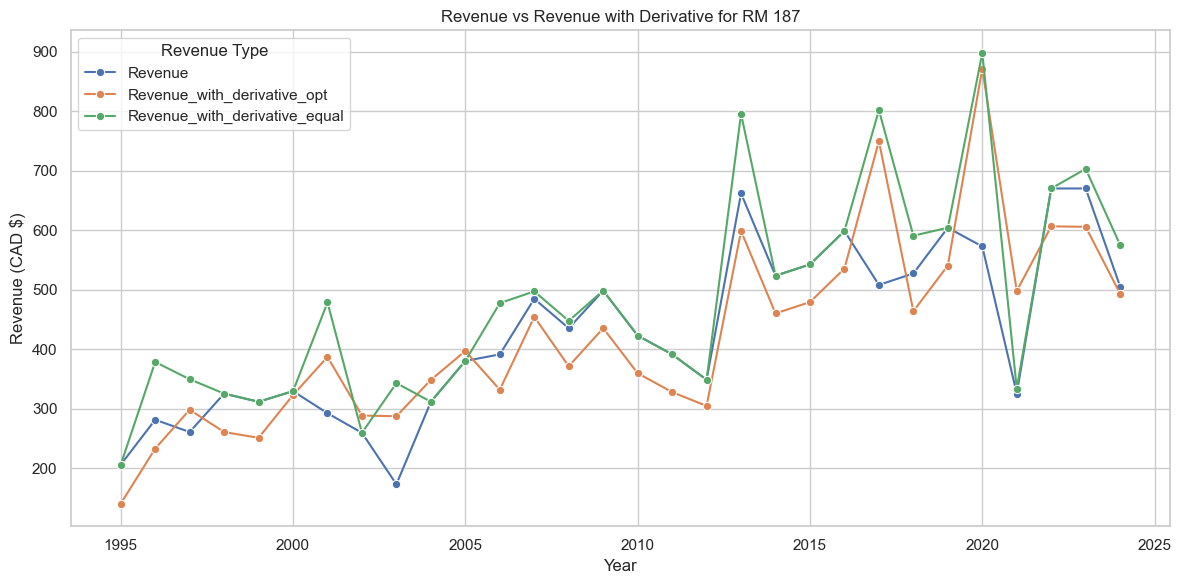

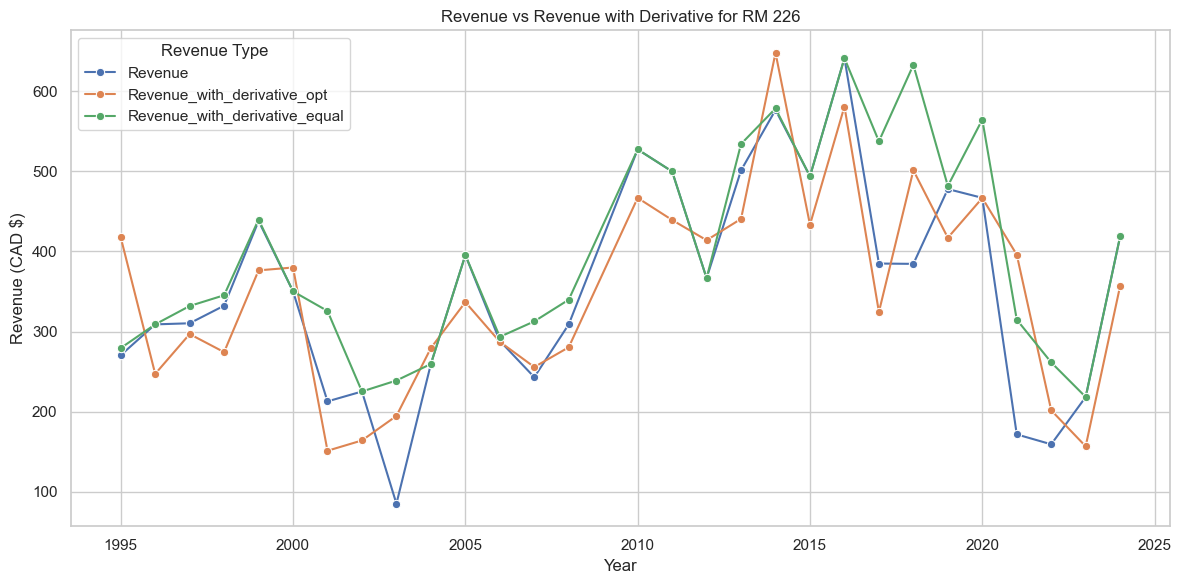

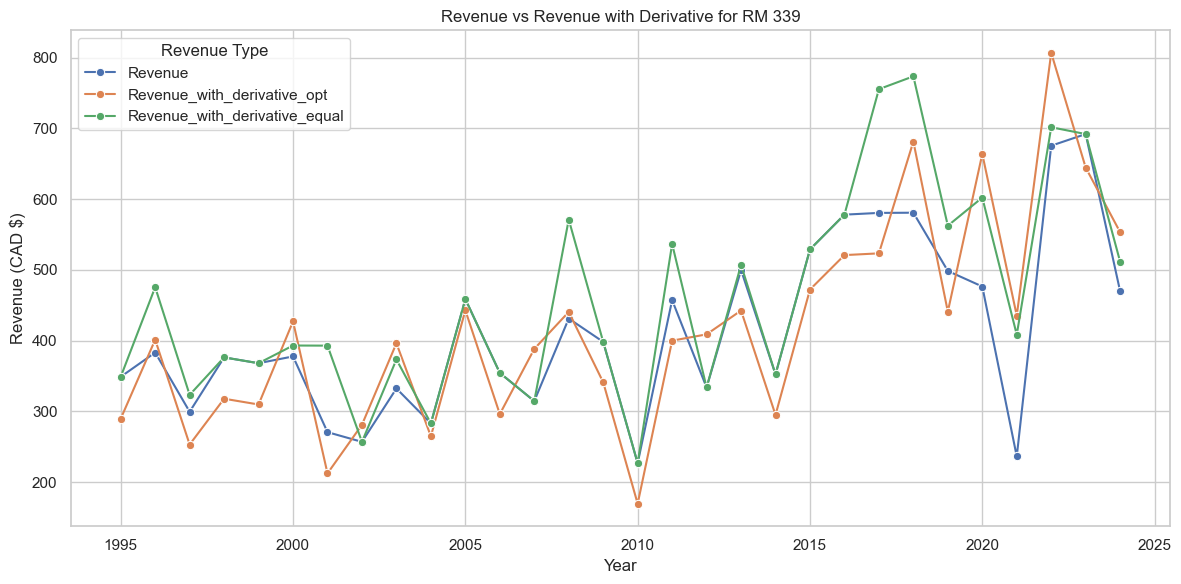

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Identify revenue columns automatically ----
revenue_cols = [c for c in df_clean.columns if c.startswith("Revenue")]
print("Revenue columns detected for plotting:", revenue_cols)

# ---- Prepare data for plotting ----
plot_df = df_clean.melt(
    id_vars=["LOCAL_YEAR", "RMs"],
    value_vars=revenue_cols,
    var_name="Revenue_Type",
    value_name="Revenue_Value"
)

# ---- Plot per RM ----
sns.set(style="whitegrid")
RMs = df_clean["RMs"].unique()

for rm in RMs:
    plt.figure(figsize=(12, 6))
    rm_data = plot_df[plot_df["RMs"] == rm]
    sns.lineplot(
        data=rm_data,
        x="LOCAL_YEAR",
        y="Revenue_Value",
        hue="Revenue_Type",
        marker="o"
    )
    plt.title(f"Revenue vs Revenue with Derivative for RM {rm}")
    plt.xlabel("Year")
    plt.ylabel("Revenue (CAD $)")
    plt.legend(title="Revenue Type")
    plt.tight_layout()
    plt.show()
